In [1]:
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry

import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt
import pickle
import pandas as pd

from utilities import single_px_retrieval

from scipy.signal import savgol_filter

from scipy.interpolate import UnivariateSpline

%matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [12]:
# exploratory single-pixel retrievals for iterative improvements

# single pixels are mean rdn values over representative pixels of each of the three classes:
# rcc vs no rcc?

In [2]:
# define file paths
home = '/store/carroll/col/data/2018/'

cal = home+'test_roi/calTarp/'
aspen = home+'test_roi/aspen/'
conifer = home+'test_roi/conifer'

extra_data = '/store/carroll/col/data/'

dir_insitu = home+'insitu/'

fp_single_px = os.path.join(home, 'test_roi/single_pxs.pkl')

fp_rccs = home + 'test_roi/rcc_white_tarp_mean_20250807.txt'

fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
wl = np.array([float(x) for x in read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

In [3]:
with open(fp_single_px, 'rb') as f:
    single_px = pickle.load(f)
rdn = single_px['rdn']

FileNotFoundError: [Errno 2] No such file or directory: '/store/carroll/col/data/2018/test_roi/single_pxs.pkl'

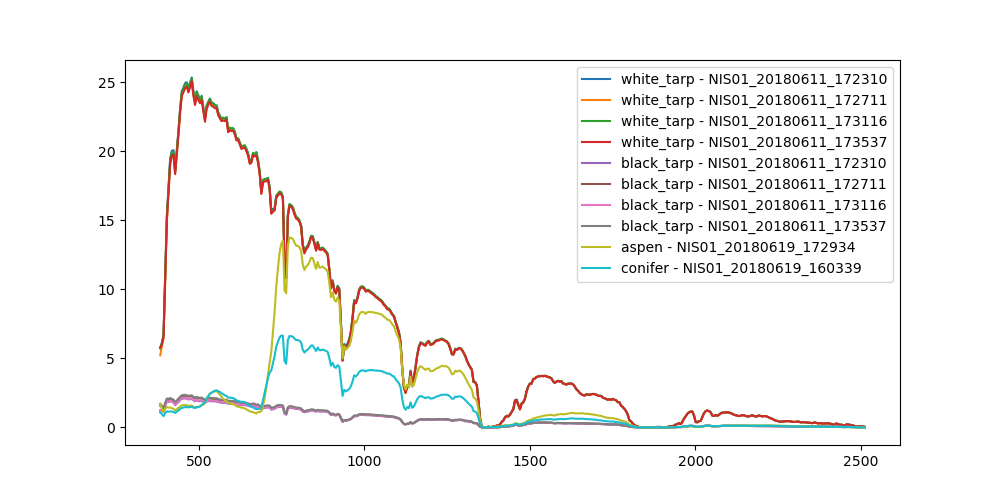

In [3]:
# load, viz representative px

with open(fp_single_px, 'rb') as f:
    single_px = pickle.load(f)
rdn = single_px['rdn']
obs = single_px['obs']
loc = single_px['loc']
bboxes = single_px['bboxes']

flights = list(rdn.keys())

fp = glob(os.path.join(cal, 'subset', f'{flights[0]}_rdn.hdr'))[0]
wl_ = [float(x) for x in read_envi_header(fp)['wavelength']]

fig = plt.figure(figsize=(10,5))
for k in ['white_tarp', 'black_tarp', 'aspen', 'conifer']:
    for f in rdn.keys():
        try:
            plt.plot(wl_, rdn[f][k], label=f'{k} - {f}')
        except: pass
plt.legend()
plt.show()

In [4]:
# set up acorn, isoft solutions from Phil
fp = glob(os.path.join(home, 'test_roi', 'aspen', 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
lit = np.sum(rgb, axis=2)
valid = lit > 5
rfl_acorn = envi.open(aspen + '/subset/min_phase_refl.hdr').open_memmap(interleave='bip').copy()/10000
rfl_isofit = envi.open(aspen + 'subset/min_phase_isofit_rfl.hdr').open_memmap(interleave='bip').copy()
rfl_acorn[valid==False,:] = np.nan
rfl_isofit[valid==False,:] = np.nan
rfl_acorn = np.nanmean(rfl_acorn, axis=(0, 1))
rfl_isofit = np.nanmean(rfl_isofit, axis=(0, 1))

INFO:root:Loading config file: /store/carroll/col/data/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet_20250731/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet_20250731/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 3721 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;

// global attributes:
	:RT_mode = transm ;
	:subset = {'AOT550': None, 'H2OSTR': None} ;
}

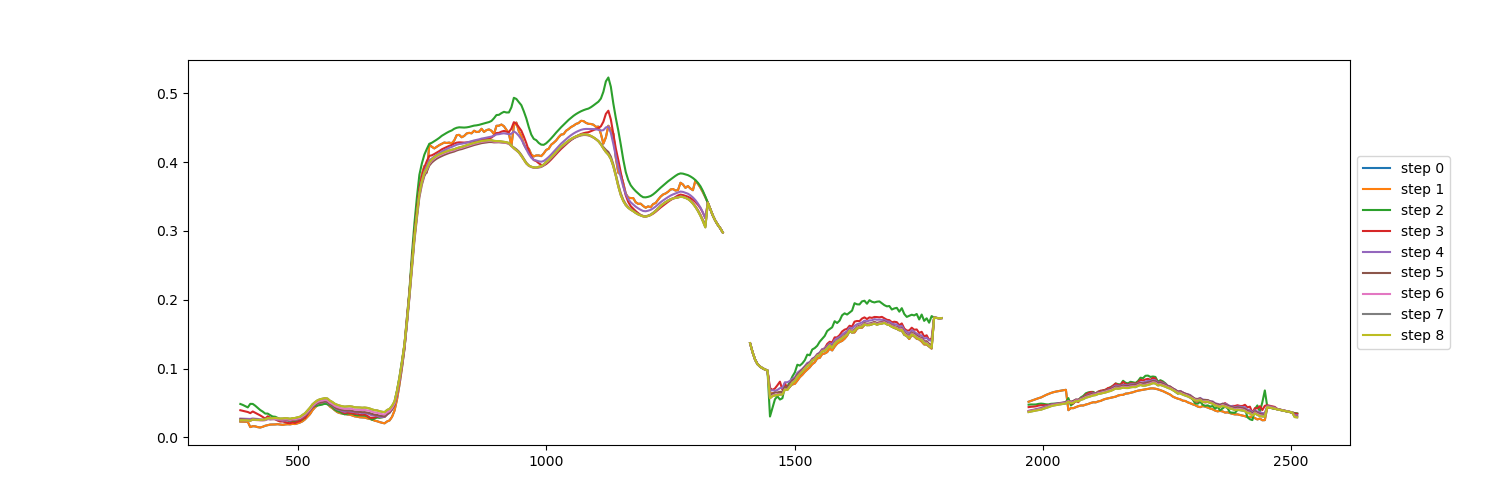

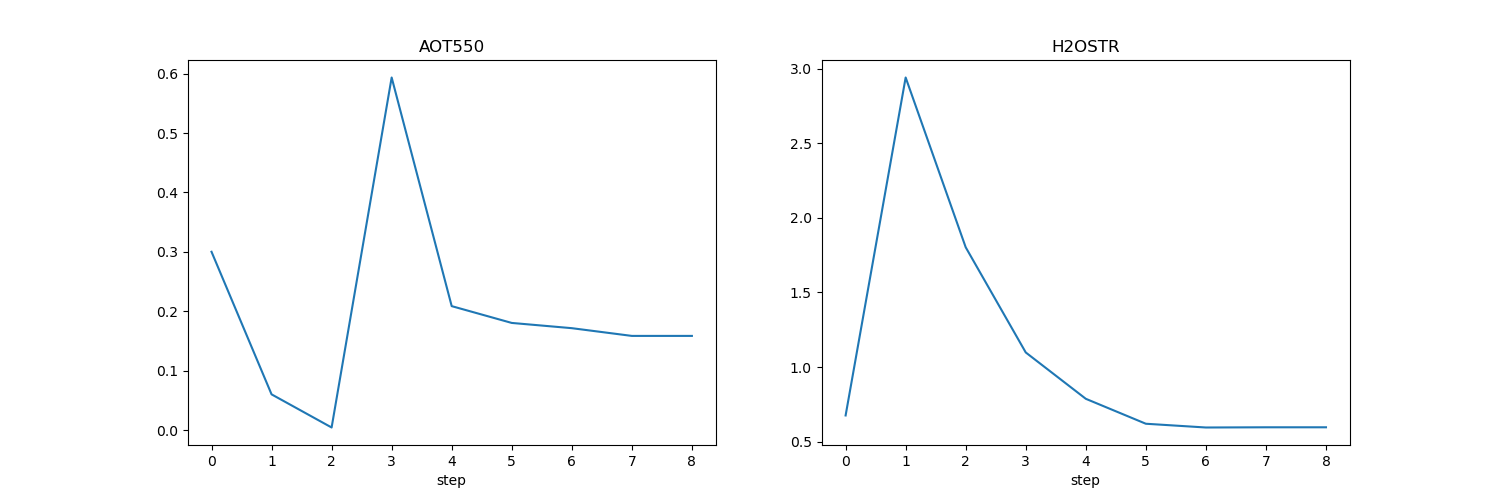

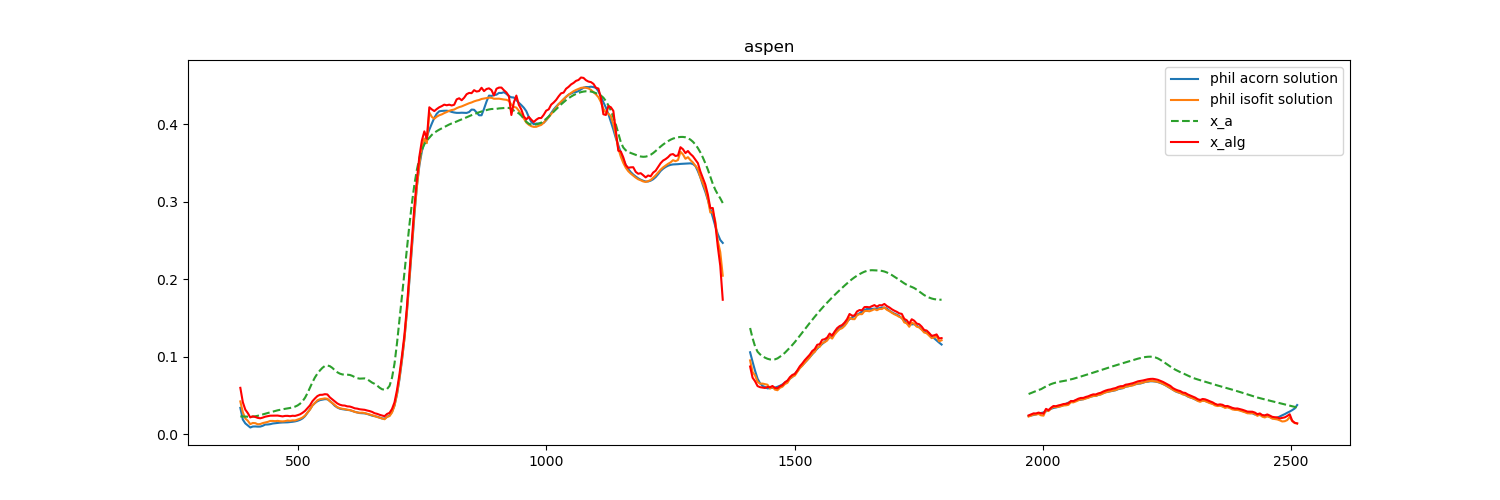

In [5]:
# aspen - NO RCC

k = 'aspen'
fol = aspen
flight = 'NIS01_20180619_172934'

# load, update config file
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# borrow the avirisng instrument model, updated to neon wavelengths?
config.forward_model.instrument.parametric_noise_file = extra_data + 'avirisng_noise_neon.txt'
config.forward_model.instrument.integrations = 2 ## post-flight report doesn't state explicitly, but this is a guess given:
    # aircraft speed = 50 m/s
    # frame rate = 100 frames/s (Hz)
    # distance per frame = 50 m/s / 100 frames / s = 0.5 m / frame ... 2 frames per pixel?
config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = extra_data + 'avirisng_systematic_error_neon.txt'
config.forward_model.model_discrepancy_file = extra_data + 'avirisng_model_discrepancy_neon.mat'

# run retrieval
x_RT, x_alg, coeffs, xa, wl = single_px_retrieval(config, rdn[flight][k], obs[flight][k], loc[flight][k])

fig = plt.figure(figsize=(15,5))
plt.plot(wl_nan, rfl_acorn, label='phil acorn solution')
plt.plot(wl_nan, rfl_isofit, label='phil isofit solution')
plt.plot(wl_nan, xa, label='x_a', ls='--')
plt.plot(wl_nan, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()

aspen_no_rcc = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/data/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet_20250731/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet_20250731/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 3721 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;

// global attributes:
	:RT_mode = transm ;
	:subset = {'AOT550': None, 'H2OSTR': None} ;
}

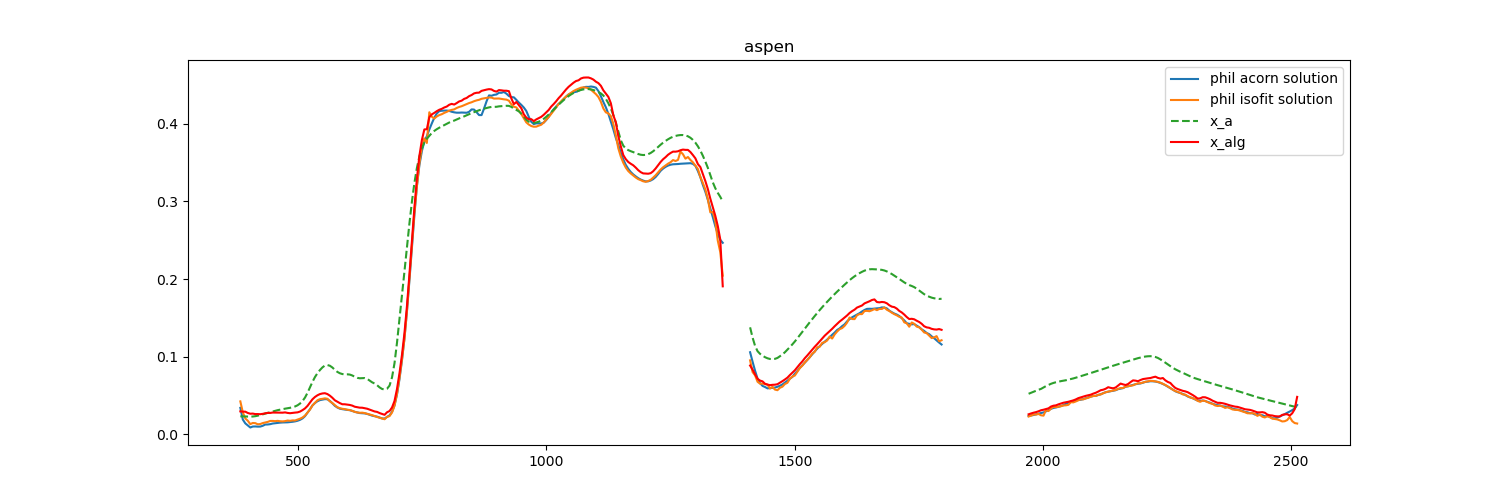

In [7]:
# aspen - mean white tarp rcc factors

# define global parameters
k = 'aspen'
fol = aspen
flight = 'NIS01_20180619_172934'
version = '20250731'

fp_surface = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat')
fp_noise = extra_data + 'avirisng_noise_neon.txt'
integrations = 2
fp_channelized_radiometric_uncertaint = extra_data + 'avirisng_systematic_error_neon.txt'
fp_model_discrepancy = extra_data + 'avirisng_model_discrepancy_neon.mat'

# load, update config file
fp_config = glob(os.path.join(fol, f'{flight}*{version}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp_config)
config.forward_model.surface.surface_file = fp_surface
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', f'{flight}_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', f'{flight}_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', f'{flight}_igm'))[0]

# borrow the avirisng instrument model, updated to neon wavelengths?
config.forward_model.instrument.parametric_noise_file = fp_noise
config.forward_model.instrument.integrations = integrations 
config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = fp_channelized_radiometric_uncertaint
config.forward_model.model_discrepancy_file = fp_model_discrepancy

# add the rccs
config.input.radiometry_correction_file = fp_rccs

# set up forward model, io, inv according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
rdn_ = rdn[flight][k]
obs_ = obs[flight][k]
loc_ = loc[flight][k]
geom = Geometry(obs=obs_, loc=loc_)

# apply the rccs
rdn_ *= io.radiance_correction

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and observed rdn
states=inv.invert(rdn_, geom)
x = states[-1,:]
x_surface, x_RT, x_instrument = fm.unpack(x)

# do a final algebraic inversion with the above solutions
x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn_, geom)

# get surface prior mean
x0 = states[0,...][fm.idx_surface].copy()
xa_full = fm.xa(x0, geom)
xa = xa_full[fm.idx_surface]

fig = plt.figure(figsize=(15,5))
plt.plot(wl_nan, rfl_acorn, label='phil acorn solution')
plt.plot(wl_nan, rfl_isofit, label='phil isofit solution')
plt.plot(wl_nan, xa, label='x_a', ls='--')
plt.plot(wl_nan, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()

aspen_rcc = x_alg.copy()

In [8]:
# load rccs for plotting
fp_out = home + 'test_roi/rcc_white_tarp_mean_20250807.txt'
rcc = np.loadtxt(fp_out)

(426,)

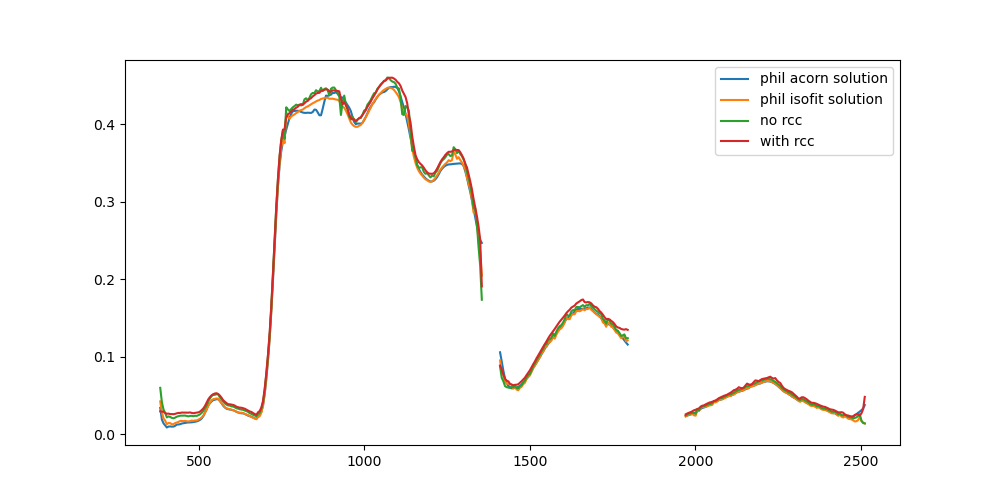

In [10]:
# no rcc vs mean white tarp rcc vs Phil previous solutions

fig = plt.figure(figsize=(10,5))
plt.plot(wl, rfl_acorn, label='phil acorn solution')
plt.plot(wl, rfl_isofit, label='phil isofit solution')
plt.plot(wl, aspen_no_rcc, label='no rcc')
plt.plot(wl, aspen_rcc, label='with rcc')

# plt.plot(wl, rcc-0.5, label='rccs')

plt.legend()
plt.show()

In [ ]:
# what happens to white, black tarp retrievals when I use the rccs

# loop through all flightlines for cal tarps

# set up dict to hold outputs 
x_algs = {k: {} for k in rdn.keys()}
rccs = {k: {} for k in rdn.keys()}

# define global parameters
version = '20250806'
fol = cal
fp_surface = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat')
fp_noise = extra_data + 'avirisng_noise_neon.txt'
integrations = 2
fp_channelized_radiometric_uncertaint = extra_data + 'avirisng_systematic_error_neon.txt'
fp_model_discrepancy = extra_data + 'avirisng_model_discrepancy_neon.mat'

for flight in flights:
    for k in ['white_tarp', 'black_tarp']:
        
        try:
            # load, update config file
            fp_config = glob(os.path.join(fol, f'{flight}*{version}', 'config', '*_isofit.json'))[0]
            config = configs.create_new_config(fp_config)
            config.forward_model.surface.surface_file = fp_surface
            config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', f'{flight}_rdn'))[0]
            config.input.obs_file = glob(os.path.join(fol, 'subset', f'{flight}_obs'))[0]
            config.input.loc_file = glob(os.path.join(fol, 'subset', f'{flight}_igm'))[0]
            
            # borrow the avirisng instrument model, updated to neon wavelengths?
            config.forward_model.instrument.parametric_noise_file = fp_noise
            config.forward_model.instrument.integrations = integrations 
            config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = fp_channelized_radiometric_uncertaint
            config.forward_model.model_discrepancy_file = fp_model_discrepancy

            # add the rccs
            config.input.radiometry_correction_file = fp_rccs
            
            # set up forward model, io, inv according to config
            fm = ForwardModel(config) # loads pre-built LUT
            io = IO(config, fm)
            inv = Inversion(config, fm)
            
            # load the isofit geometry representation of the single pixel
            rdn_ = rdn[flight][k]
            obs_ = obs[flight][k]
            loc_ = loc[flight][k]
            geom = Geometry(obs=obs_, loc=loc_)
            
            # apply the rccs
            rdn_ *= io.radiance_correction
            
            # run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and observed rdn
            states=inv.invert(rdn_, geom)
            x = states[-1,:]
            x_surface, x_RT, x_instrument = fm.unpack(x)
    
            # do a final algebraic inversion with the above solutions
            x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                                 x_surface, x_RT, x_instrument,
                                                 rdn_, geom)
            # get surface prior mean
            x0 = states[0,...][fm.idx_surface].copy()
            xa_full = fm.xa(x0, geom)
            xa = xa_full[fm.idx_surface]
    
            # get single px rcc
            fp_rfl = home + f'/insitu/cal_{k}_neon.txt'
            insitu_rfl = np.loadtxt(fp_rfl)[:,1]
            modeled_rdn = fm.calc_meas(x, geom, insitu_rfl)
            rcc_ = modeled_rdn/rdn_
            
            # final rfl solution w/ in situ
            if k=='white_tarp':
                fps = glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat'))
            else: fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
            fig = plt.figure(figsize=(15,5))
            for fp in fps:
                in_situ = np.genfromtxt(fp, skip_header=3)
                plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
            plt.plot(wl, xa, label='x_a', ls='--')
            plt.plot(wl, x_alg, label='x_alg', c='red')
            plt.title(f'{k}')
            plt.legend()
            plt.show()
            
            x_algs[flight][k] = x_alg
            rccs[flight][k] = rcc_
            
        except Exception as e:
            print(f"Error for flight {flight}, key {k}: {e}")

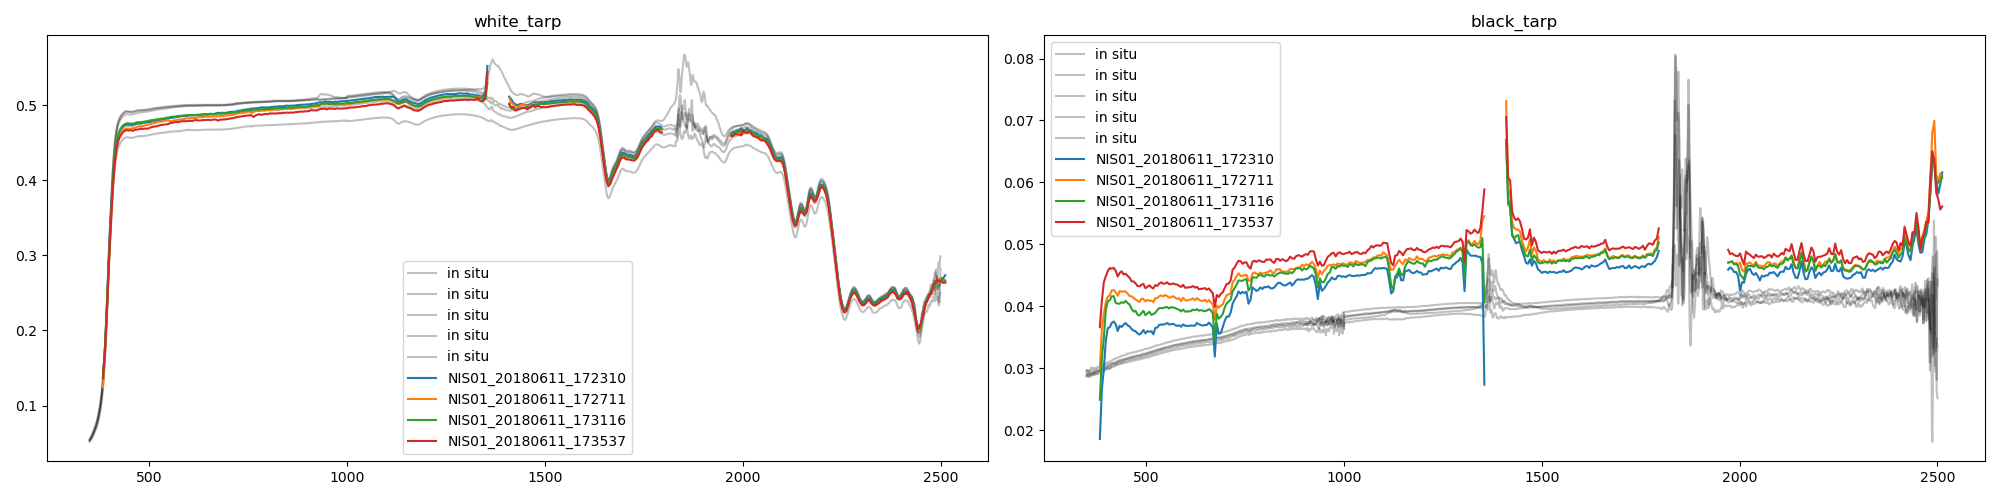

In [16]:
# look at the final algebraic surface solution from each flightline

fig, axs = plt.subplots(ncols=2, figsize=(20,5))

# plot rccs to visualize alongisde retrievals
# axs[0].plot(wl, rcc-0.5, label='rccs')
# axs[1].plot(wl, rcc-0.9, label='rccs')

# plot in situ rfl
fps = glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat')) + glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
for fp in fps:
    if 'white' in fp:
        i = 0
    else: i=1
    in_situ = np.genfromtxt(fp, skip_header=3)
    axs[i].plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)

for flight in x_algs.keys():
    for k in x_algs[flight].keys():
        try:
            rfl_ = x_algs[flight][k]
            if k=='white_tarp':
                i=0
            else: i=1
            axs[i].plot(wl, rfl_, label=flight)
            axs[i].set_title(k)
            axs[i].legend()
        except: pass

plt.tight_layout()
plt.show()